# 마지막 블록 CLS 어텐션 → 히트맵 만들기

질문: **마지막 블록 어텐션에서 CLS 히트맵을 만드는 절차는?**

답:
$$
A^{(h)} = \mathrm{softmax}\!\left(\frac{q^{(h)} k^{(h)\top}}{\sqrt{d_h}}\right)
\in \mathbb{R}^{(1+P)\times(1+P)}
\quad\Longrightarrow\quad
a^{(h)} = A^{(h)}[0,\ 1:] \in \mathbb{R}^{P}
$$
를 $\sqrt{P}\times\sqrt{P}$ 로 reshape하고 `patch_size` 배 업샘플.

이 스크립트는 실제 DINO 저장소의 `vision_transformer.py` 를 import해서
**각 단계의 shape이 정말 그렇게 흐르는지** 눈으로 확인한다.

> **중요**: 아래 모델은 **랜덤 초기화 가중치**다. 따라서 히트맵이 물체를 찾지 못한다.
> (랜덤 어텐션은 거의 균일한 흐릿한 노이즈다.) 여기서 검증하는 것은
> **shape 흐름과 인덱싱 규칙**이지 "DINO가 물체를 찾는다"는 결과가 아니다.
> 진짜 결과를 보려면 공식 가중치를 로드해야 한다 (아래 셀 주석 참고).

In [1]:
# 필요 패키지: torch(2.4), numpy, plotly(6.9), kaleido
import os
import sys

import numpy as np
import torch
import torch.nn as nn
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# DINO 저장소를 import 경로에 추가 (실제 ViT 구현을 그대로 쓴다)
sys.path.insert(0, "/home/sungwoo/projects/swcho/dino")
import vision_transformer as vits  # noqa: E402

torch.manual_seed(0)
np.random.seed(0)

HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()


def _show(fig):
    try:
        from IPython import get_ipython

        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


print("torch", torch.__version__)

torch 2.4.0+cu121


## 1. 모델과 합성 이미지

`vit_tiny(patch_size=16)`: `embed_dim=192`, `depth=12`, **`num_heads=3`**.
입력 $224\times224$ 이면 패치 수 $P = (224/16)^2 = 14^2 = 196$,
토큰 수 $N = 1 + P = 197$ (맨 앞 1개가 `[CLS]`).

이미지는 어두운 배경 위에 **밝은 사각형 + 원**을 그린 합성 이미지.
ImageNet 통계로 정규화해서 넣는다 (실제 `visualize_attention.py` 와 동일한 전처리).

In [2]:
PATCH = 16
IMG = 224

model = vits.vit_tiny(patch_size=PATCH, num_classes=0)
model.eval()
for p in model.parameters():
    p.requires_grad = False

# 공식 사전학습 가중치를 쓰고 싶다면 (ViT-S/16 기준):
#   import utils
#   model = vits.vit_small(patch_size=16, num_classes=0)
#   utils.load_pretrained_weights(model, "", "teacher", "vit_small", 16)
#   # pretrained_weights="" 이면 utils가 torch.hub로 공식 체크포인트를 내려받는다.

# --- 합성 이미지: 배경(0.15) + 밝은 사각형 + 밝은 원 ---
raw = np.full((3, IMG, IMG), 0.15, dtype=np.float32)
raw[0, 40:110, 40:110] = 0.90  # 왼쪽 위 사각형 (붉은기)
raw[1, 40:110, 40:110] = 0.60
yy, xx = np.mgrid[0:IMG, 0:IMG]
circle = (yy - 150) ** 2 + (xx - 160) ** 2 < 45**2
raw[1][circle] = 0.95  # 오른쪽 아래 원 (녹/청)
raw[2][circle] = 0.85

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)[:, None, None]
STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)[:, None, None]
img = torch.from_numpy((raw - MEAN) / STD).unsqueeze(0)  # (1, 3, 224, 224)

print("입력 img          :", tuple(img.shape))
print("패치 격자 w_featmap:", img.shape[-2] // PATCH, "x", img.shape[-1] // PATCH)
print("토큰 수 N = 1 + P  :", 1 + (img.shape[-2] // PATCH) * (img.shape[-1] // PATCH))

입력 img          : (1, 3, 224, 224)
패치 격자 w_featmap: 14 x 14
토큰 수 N = 1 + P  : 197


## 2. 마지막 블록의 어텐션 행렬 $A$

`get_last_selfattention` 은 마지막 블록만 `return_attention=True` 로 호출해
`Attention.forward` 안의
```python
attn = (q @ k.transpose(-2, -1)) * self.scale   # self.scale = d_h ** -0.5
attn = attn.softmax(dim=-1)
```
결과를 그대로 돌려준다. 즉 반환값이 곧 $A \in \mathbb{R}^{(B,\,H,\,N,\,N)}$.

헤드 차원 $d_h = 192/3 = 64$, `self.scale` $= 1/\sqrt{64} = 0.125$.

In [3]:
with torch.no_grad():
    attn = model.get_last_selfattention(img)

nh = attn.shape[1]
print("A                 :", tuple(attn.shape), " = (B, heads, 1+P, 1+P)")
print("헤드 수 nh        :", nh)
print("d_h               :", 192 // nh, " scale =", (192 // nh) ** -0.5)

A                 : (1, 3, 197, 197)  = (B, heads, 1+P, 1+P)
헤드 수 nh        : 3
d_h               : 64  scale = 0.125


## 3. softmax니까 **각 행의 합이 1**

$A[b,h,i,:]$ 는 "query 토큰 $i$ 가 전체 토큰에 나눠준 주의 확률분포"다.
`softmax(dim=-1)` 이므로 행 단위 합이 1.

이 때문에 히트맵 값의 **절대 크기를 헤드 간에 그대로 비교하면 안 된다**:
어떤 헤드가 CLS 자기 자신(열 0)에 질량을 많이 남기면 패치 쪽 합은 1보다 작아진다.
실제로 우리가 꺼내는 `[0, :, 0, 1:]` 는 열 0을 버리므로 합이 정확히 1이 아니다.

In [4]:
row_sums = attn.sum(dim=-1)
print("모든 행 합 ≈ 1     :", torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-5))
print("CLS 행 전체 합     :", attn[0, :, 0, :].sum(dim=-1).tolist())
print("CLS→패치만 합(열1:):", [round(v, 4) for v in attn[0, :, 0, 1:].sum(dim=-1).tolist()])
print("CLS→CLS (열 0)     :", [round(v, 4) for v in attn[0, :, 0, 0].tolist()])

모든 행 합 ≈ 1     : True
CLS 행 전체 합     : [1.0, 1.0, 1.0000001192092896]
CLS→패치만 합(열1:): [0.9952, 0.9954, 0.9952]
CLS→CLS (열 0)     : [0.0048, 0.0046, 0.0048]


## 4. 인덱싱 `[0, :, 0, 1:]` 의 의미

| 축 | 인덱스 | 뜻 |
|---|---|---|
| 0 (batch) | `0` | 배치의 첫 이미지 |
| 1 (head) | `:` | 모든 헤드 (헤드별 히트맵을 각각 얻는다) |
| 2 (query) | `0` | **query = `[CLS]` 토큰의 행** |
| 3 (key) | `1:` | key = 패치 토큰들 (CLS 자기 자신인 열 0 제외) |

query 축이 CLS인 이유: `[CLS]` 는 "이미지 전체를 하나로 요약"하도록 학습되는 토큰이고,
그 요약을 만들 때 **어느 패치에서 값을 끌어왔는가**가 곧 $A[0, 1:]$ 행이다.
→ "무엇을 보고 요약했는가"의 지도.

그 다음 shape 흐름:
$(H, P) \to \texttt{reshape}(H, \sqrt P, \sqrt P) \to
\texttt{interpolate}(\times \texttt{patch\_size}) \to (H, 224, 224)$.

In [5]:
w_featmap = img.shape[-2] // PATCH
h_featmap = img.shape[-1] // PATCH  # 비정사각 입력도 이렇게 각 축을 따로 나눈다

step1 = attn[0, :, 0, 1:]                       # (nh, P)
print("step1  [0,:,0,1:]        :", tuple(step1.shape))

step2 = step1.reshape(nh, w_featmap, h_featmap)  # (nh, 14, 14)
print("step2  reshape 격자      :", tuple(step2.shape))

step3 = nn.functional.interpolate(
    step2.unsqueeze(0), scale_factor=PATCH, mode="nearest"
)[0]                                             # (nh, 224, 224)
print("step3  interpolate x16   :", tuple(step3.shape))

heat = step3.cpu().numpy()
print("값 범위                  :", float(heat.min()), "~", float(heat.max()))
print("균일 어텐션 기준선 1/P   :", 1 / (w_featmap * h_featmap))

step1  [0,:,0,1:]        : (3, 196)
step2  reshape 격자      : (3, 14, 14)
step3  interpolate x16   : (3, 224, 224)
값 범위                  : 0.00398306455463171 ~ 0.005628954153507948
균일 어텐션 기준선 1/P   : 0.00510204081632653


## 5. `nearest` vs `bilinear`

원본 `visualize_attention.py` 는 `mode="nearest"` 를 쓴다.
어텐션 값은 **패치 단위의 이산 측정값**이므로, nearest는 $16\times16$ 블록을
그대로 확대해 "패치 경계가 보이는" 정직한 그림을 준다.
bilinear는 보기엔 매끈하지만 패치 사이에 **없던 값을 만들어낸다**.

In [6]:
bil = nn.functional.interpolate(
    step2.unsqueeze(0), scale_factor=PATCH, mode="bilinear", align_corners=False
)[0]
print("nearest  고유값 개수:", len(torch.unique(step3[0])))   # = 패치 수 그대로
print("bilinear 고유값 개수:", len(torch.unique(bil[0])))     # 보간으로 값이 늘어남
print("nearest 최대/최소 == 패치 최대/최소:",
      torch.allclose(step3[0].max(), step2[0].max()),
      torch.allclose(step3[0].min(), step2[0].min()))

nearest  고유값 개수: 196
bilinear 고유값 개수: 38841
nearest 최대/최소 == 패치 최대/최소: True True


## 6. 헤드별 히트맵 + 평균/최대 결합 시각화

헤드마다 보는 곳이 다르다(사전학습 모델에서는 어떤 헤드는 물체 전체, 어떤 헤드는
경계나 특정 부위). 한 장으로 요약하려면 헤드 축으로 **평균**(부드럽지만 흐림)
또는 **최대**(어떤 헤드든 본 곳을 살림, 대신 노이즈에 민감)를 취한다.

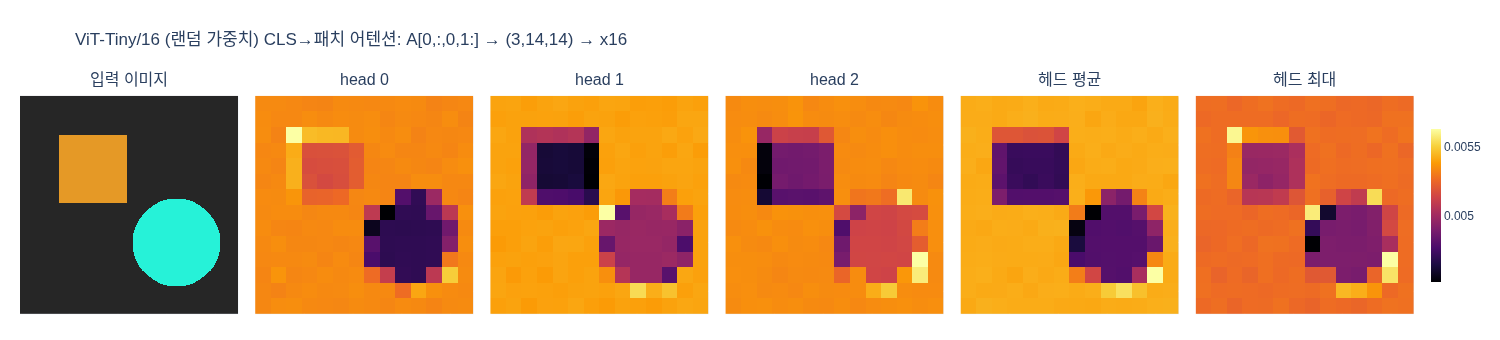

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/1fcac607-93f2-48af-84c6-edeb79c46da4/expy.png


In [7]:
denorm = np.clip(raw.transpose(1, 2, 0), 0, 1)  # (224, 224, 3), 표시용 원본
mean_head = heat.mean(axis=0)
max_head = heat.max(axis=0)

titles = ["입력 이미지"] + [f"head {h}" for h in range(nh)] + ["헤드 평균", "헤드 최대"]
fig = make_subplots(rows=1, cols=len(titles), subplot_titles=titles,
                    horizontal_spacing=0.012)
fig.add_trace(go.Image(z=(denorm * 255).astype(np.uint8)), row=1, col=1)
for i, m in enumerate([heat[h] for h in range(nh)] + [mean_head, max_head]):
    fig.add_trace(
        go.Heatmap(z=m, colorscale="Inferno", showscale=(i == len(titles) - 2),
                   colorbar=dict(len=0.75, thickness=10, x=1.005)),
        row=1, col=i + 2,
    )
fig.update_yaxes(autorange="reversed", scaleanchor="x", constrain="domain",
                 showticklabels=False)
fig.update_xaxes(showticklabels=False, constrain="domain")
fig.update_layout(
    title=f"ViT-Tiny/{PATCH} (랜덤 가중치) CLS→패치 어텐션: A[0,:,0,1:] → (3,14,14) → x16",
    width=1500, height=340, margin=dict(l=20, r=60, t=90, b=20),
)
_show(fig)

png_path = os.path.join(HERE, "expy.png")
fig.write_image(png_path, scale=2)
print("saved:", png_path)

> 그림에 사각형·원의 윤곽이 흐릿하게 비치지만, **이건 DINO가 물체를 찾은 게 아니다.**
> 컬러바를 보면 값이 $0.0040 \sim 0.0056$, 즉 균일 어텐션 $1/196 \approx 0.0051$ 에서
> $\pm 10\%$ 밖에 안 벗어난다. 게다가 부호가 **반대**다 — 물체 쪽이 오히려 어둡다.
> 랜덤 patch embedding이 밝기에 무작위로 반응한 흔적일 뿐이다.
> 사전학습 DINO 가중치에서는 CLS 어텐션이 객체 실루엣 위에 수십 배 차이로 뭉친다.
> 여기서 검증한 것은 **shape 흐름과 인덱싱 규칙**이고, 그건 정확히 동일하다.
>
> 한편 $16\times16$ **블록이 또렷이 보이는 것**은 `mode="nearest"` 업샘플의 정직한 결과다
> (§5). 히트맵의 실제 해상도는 $224$ 가 아니라 $14\times14$ 라는 사실이 눈에 보인다.

## 7. `--threshold 0.6`: 어텐션 질량 60%를 덮는 패치만 남기기

`visualize_attention.py` 의 코드를 그대로 옮기면:
```python
val, idx = torch.sort(attentions)          # 오름차순 정렬 (작은 값이 앞)
val /= torch.sum(val, dim=1, keepdim=True) # 합 1로 재정규화
cumval = torch.cumsum(val, dim=1)          # 누적합
th_attn = cumval > (1 - threshold)         # 하위 40% 질량은 버림
idx2 = torch.argsort(idx)                  # 정렬 → 원래 패치 순서로 되돌리는 순열
th_attn[head] = th_attn[head][idx2[head]]
```
오름차순 누적합이 $1-0.6 = 0.4$ 를 넘는 지점부터 True → **상위 60% 질량**을 차지하는
패치들만 남는다. `idx2 = argsort(idx)` 가 핵심: `idx` 는 "정렬 위치 → 원래 위치" 이고
그 argsort가 "원래 위치 → 정렬 위치" 라서, 정렬 순서 마스크를 원래 격자로 되돌려준다.

In [8]:
THRESHOLD = 0.6
attentions = attn[0, :, 0, 1:].reshape(nh, -1)  # (nh, P)

val, idx = torch.sort(attentions)
val = val / torch.sum(val, dim=1, keepdim=True)
cumval = torch.cumsum(val, dim=1)
th_attn = cumval > (1 - THRESHOLD)
idx2 = torch.argsort(idx)
for head in range(nh):
    th_attn[head] = th_attn[head][idx2[head]]
th_attn = th_attn.reshape(nh, w_featmap, h_featmap).float()

kept = th_attn.flatten(1).sum(1).tolist()
print(f"threshold={THRESHOLD} → 헤드별 남은 패치 수 (전체 {w_featmap*h_featmap}):", kept)
print("남은 패치가 차지하는 실제 어텐션 질량:",
      [round(v, 3) for v in
       (attentions * th_attn.reshape(nh, -1)).sum(1).div(attentions.sum(1)).tolist()])

th_up = nn.functional.interpolate(th_attn.unsqueeze(0), scale_factor=PATCH,
                                  mode="nearest")[0]
print("마스크 업샘플 shape:", tuple(th_up.shape))

threshold=0.6 → 헤드별 남은 패치 수 (전체 196): [115.0, 114.0, 115.0]
남은 패치가 차지하는 실제 어텐션 질량: [0.603, 0.604, 0.604]
마스크 업샘플 shape: (3, 224, 224)


랜덤 가중치라 어텐션이 거의 균일 → 60% 질량을 덮는 데 패치의 **절반쯤**이 필요하다.
사전학습 DINO에서는 어텐션이 물체에 집중되어 훨씬 적은 패치(수십 개)만 남고,
그게 곧 "공짜로 얻은 분할 마스크"가 된다.

## 8. 해상도 · patch_size 에 따른 토큰 수와 어텐션 행렬 메모리

어텐션 행렬은 $(B, H, N, N)$ 이고 $N = 1 + (\text{img}/\text{patch})^2$.
`Attention.forward` 가 `attn` 을 항상 반환하도록 되어 있어
`F.scaled_dot_product_attention`(FlashAttention)을 못 쓰고 이 $N\times N$ 이 항상 메모리에 뜬다.
patch 16 → 8 은 $N$ 이 4배, 메모리는 **약 16배**.

In [9]:
print(f"{'img':>5} {'patch':>6} {'grid':>8} {'N':>7} {'A shape (1,3,N,N)':>22} {'fp32 MB':>9}")
for img_sz in (96, 224, 448):
    for ps in (16, 8):
        g = img_sz // ps
        N = 1 + g * g
        mb = 1 * nh * N * N * 4 / 1024**2
        print(f"{img_sz:>5} {ps:>6} {f'{g}x{g}':>8} {N:>7} {f'(1,{nh},{N},{N})':>22} {mb:>9.2f}")

  img  patch     grid       N      A shape (1,3,N,N)   fp32 MB
   96     16      6x6      37            (1,3,37,37)      0.02
   96      8    12x12     145          (1,3,145,145)      0.24
  224     16    14x14     197          (1,3,197,197)      0.44
  224      8    28x28     785          (1,3,785,785)      7.05
  448     16    28x28     785          (1,3,785,785)      7.05
  448      8    56x56    3137        (1,3,3137,3137)    112.62


patch 8 은 격자가 촘촘해 히트맵이 훨씬 선명하지만 (논문 그림도 ViT-S/8),
위 표대로 어텐션 행렬 메모리가 patch 16 대비 **16배**다.

## 9. 다른 해상도로 실제 실행 — 비정사각 입력도 확인

ViT는 `interpolate_pos_encoding` 으로 위치 임베딩을 늘려주므로 224가 아니어도 된다.
다만 각 변이 `patch_size` 의 배수여야 하고, 격자는
`w_featmap = img.shape[-2] // patch_size`, `h_featmap = img.shape[-1] // patch_size`
로 **축마다 따로** 계산해야 한다 ($\sqrt P$ 로 뭉뚱그리면 비정사각에서 깨진다).

In [10]:
for shape in [(96, 96), (144, 96), (256, 160)]:
    x = torch.randn(1, 3, *shape)
    with torch.no_grad():
        a = model.get_last_selfattention(x)
    wf, hf = shape[0] // PATCH, shape[1] // PATCH
    cls_map = a[0, :, 0, 1:].reshape(nh, wf, hf)
    up = nn.functional.interpolate(cls_map.unsqueeze(0), scale_factor=PATCH,
                                   mode="nearest")[0]
    print(f"입력{shape} → A{tuple(a.shape)} → 격자({wf},{hf}) → 히트맵{tuple(up.shape)}")

입력(96, 96) → A(1, 3, 37, 37) → 격자(6,6) → 히트맵(3, 96, 96)
입력(144, 96) → A(1, 3, 55, 55) → 격자(9,6) → 히트맵(3, 144, 96)
입력(256, 160) → A(1, 3, 161, 161) → 격자(16,10) → 히트맵(3, 256, 160)


### 요약 (절차 5줄)

1. `a = model.get_last_selfattention(img)` → $(1, H, 1+P, 1+P)$ — 이미 softmax된 $A$
2. `a[0, :, 0, 1:]` → $(H, P)$ — 배치 0 / 모든 헤드 / **query=CLS(행 0)** / **key=패치(열 1:)**
3. `.reshape(H, w_featmap, h_featmap)` → $(H, \sqrt P, \sqrt P)$ — 1D 패치 순서를 2D 격자로
4. `F.interpolate(..., scale_factor=patch_size, mode="nearest")` → $(H, 224, 224)$
5. (선택) 정렬–누적합–역정렬로 상위 질량 60% 마스크 → 분할처럼 보이는 그림